# 01. Padding and the fifteen minute line

Two questions from the first half of the story. How much of a flight's scheduled time is there to
absorb delay, and has that grown? And do carriers' arrivals pile up just under the fifteen minute
line that decides what counts as on time?

The dead end is kept in the middle: a padding reference recomputed every year. It looks more
careful and it hides the very growth the chapter measures. The simulator shows why, with the truth
known; then the real flights, read from the committed marts and the manifest.

In [1]:
import json
import os
from pathlib import Path

import duckdb
import numpy as np
import polars as pl

pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_fmt_str_lengths(90)
pl.Config.set_tbl_width_chars(160)
pl.Config.set_float_precision(3)
ROOT = Path(os.environ.get("TURNAROUND_NOTEBOOK_ROOT") or (Path.cwd() if (Path.cwd() / "results").exists() else Path.cwd().parent))
manifest = json.loads((ROOT / "results" / "manifest.json").read_text(encoding="utf-8"))
values, tables = manifest["values"], manifest["tables"]


def v(key):
    return values[key]["value"]


def t(key):
    # A manifest value formatted the way the documents print it.
    from turnaround_core.formats import format_value

    return format_value(values[key]["value"], values[key]["fmt"])


def table(key):
    entry = tables[key]
    return pl.DataFrame(entry["rows"], schema=entry["columns"], orient="row")


MARTS = ROOT / "results" / "marts"
print("manifest as of", manifest["as_of"], "with", len(values), "values;", "window", v("data.first_month"), "to", v("data.last_month"))

manifest as of 2026-10-01 with 625 values; window January 2015 to July 2026


## The reference that drifted with congestion: a dead end, kept

Padding is scheduled block time minus unimpeded block time, the gate to gate time beaten by only a
tenth of flights on the same route, in the same three hour block and season. The question is which
years the tenth percentile is taken over.

Taking it over each year's own flights is the obvious choice and the wrong one. When congestion
slows every flight, the tenth percentile rises with it, and padding measured against a floor that
rises with the delay cannot show the schedule growing to cover that delay. Below, two simulated
years with known padding; in the second year every flight takes six minutes longer and every
schedule grows by the same six minutes, the way a carrier rebuilds its timetable. The truth is that
the schedule grew by six minutes plus whatever padding the carriers added.

In [2]:
from turnaround_chapters import padding
from turnaround_sim.network import SimSpec, simulate

CONGESTION = 6.0
sim = simulate(SimSpec(seed=11, days=730, start="2022-01-01", meltdown_day=600))
slower = pl.when(pl.col("year") == 2023).then(CONGESTION).otherwise(0.0)
flights = sim.flights.with_columns(
    (pl.col("actual_elapsed").cast(pl.Float64) + slower).alias("actual_elapsed"),
    (pl.col("crs_elapsed").cast(pl.Float64) + slower).alias("crs_elapsed"),
)
con = duckdb.connect()
con.register("flights", flights.to_arrow())
true_padding = dict(con.execute("select year, avg(true_padding) from flights where not cancelled group by 1").fetchall())
truth = CONGESTION + true_padding[2023] - true_padding[2022]

padding.build_unimpeded(con, "flights", where_fit="year = 2022", percentile=0.10, min_flights=30, target="fixed")
fixed = dict(con.execute(f"select year, avg(padding) from ({padding.padded_flights_sql('flights', 'fixed')}) group by 1").fetchall())
yearly = {}
for year in (2022, 2023):
    padding.build_unimpeded(con, "flights", where_fit=f"year = {year}", percentile=0.10, min_flights=30, target=f"ref_{year}")
    yearly[year] = con.execute(
        f"select avg(padding) from ({padding.padded_flights_sql('flights', f'ref_{year}')}) where year = {year}"
    ).fetchone()[0]
pl.DataFrame(
    {
        "": ["the truth: schedule growth over the first year's unimpeded time", "reference fixed on the first year", "reference recomputed every year"],
        "change in padding, minutes": [truth, fixed[2023] - fixed[2022], yearly[2023] - yearly[2022]],
    }
)

,"change in padding, minutes"
str,f64
"""the truth: schedule growth over the first year's unimpeded time""",6.481
"""reference fixed on the first year""",6.524
"""reference recomputed every year""",0.516


The fixed reference recovers the schedule's growth; the yearly one reports only the padding the
carriers added on top and loses the six minutes the schedule grew to absorb the congestion. That is
the growth chapter 2 is about, so the reference is fixed on the fitting years, 2015 to 2022, and
held there (`packages/chapters/src/turnaround_chapters/padding.py`). The cost is stated in the
chapter's pushback: a fixed reference treats a route that genuinely got slower to fly, a new
approach procedure or a longer taxi, as if the airline had padded it.

## Padding on the real flights

In [3]:
route_month = pl.read_parquet(MARTS / "mart_route_month.parquet")
by_year = (
    route_month.group_by("year")
    .agg(
        pl.col("padding_flights").sum().alias("flights with a reference"),
        (pl.col("padding_sum").sum() / pl.col("padding_flights").sum()).alias("mean padding, min"),
        (pl.col("crs_elapsed_sum").sum() / pl.col("flown").sum()).alias("mean scheduled block, min"),
        (pl.col("actual_elapsed_sum").sum() / pl.col("flown").sum()).alias("mean actual block, min"),
    )
    .sort("year")
)
print("padding change on matched cells:", t("ch2.padding.change"), "from", v("ch2.first_year"), "to", v("ch2.last_year"))
by_year

padding change on matched cells: +3.98 min from 2015 to 2025


year,flights with a reference,"mean padding, min","mean scheduled block, min","mean actual block, min"
i32,i64,f64,f64,f64
2015,5798458,16.794,141.894,137.006
2016,5603663,17.509,145.515,140.161
2017,5660617,18.358,147.096,141.762
2018,7157890,18.459,141.379,136.529
2019,7366792,19.169,142.121,136.690
2020,4633759,17.791,138.090,131.077
2021,5913621,18.438,143.042,136.799
2022,6630817,18.561,143.004,137.510
2023,6594912,19.630,145.873,140.298


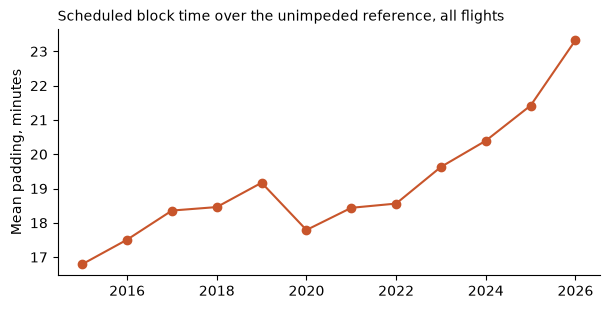

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(by_year["year"], by_year["mean padding, min"], color="#C8552B", marker="o")
ax.set_ylabel("Mean padding, minutes")
ax.set_title("Scheduled block time over the unimpeded reference, all flights", loc="left", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

The yearly means above mix routes; the chapter's own estimate holds the route, hour and month
fixed (matched cells), which is the number printed above the table and in the story.

## The fifteen minute line

Every flight under fifteen minutes late counts as on time. If schedules or gate procedures aim at
the line, arrivals pile up just under it and thin out just over it. The density test compares the
bunching at fifteen with the same statistic at placebo thresholds where nothing is at stake.

In [5]:
from turnaround_stats.density import density_test

histogram = pl.read_parquet(MARTS / "mart_delay_histogram.parquet")
first_test_year = int(v("policy.test_first_year"))
pooled = (
    histogram.filter(pl.col("year") >= first_test_year)
    .group_by("minute").agg(pl.col("flights").sum()).sort("minute")
)
test = density_test(pooled["minute"].to_numpy().astype(np.int64), pooled["flights"].to_numpy().astype(np.float64))
print(f"pooled over carriers, {first_test_year} onward: statistic {test.statistic:.4f}, z against {test.placebos_evaluated} placebos {test.z:.2f}, rank p {test.rank_p_value:.3f}")
pooled.filter(pl.col("minute").is_between(8, 22))

pooled over carriers, 2023 onward: statistic -0.0087, z against 49 placebos -2.40, rank p 0.960


minute,flights
i32,i64
8,253781
9,237910
10,225157
11,210342
12,199553
13,188600
14,177661
15,168379
16,159045


The chapter runs the same test per carrier with Benjamini-Hochberg across carriers; its verdict,
either way, is in the story and in `results/manifest.json` under `ch3`.

In [6]:
table("ch3.by_carrier")

Carrier,Flights,Excess below the line,z against placebos,p,q (BH),Verdict
str,i64,f64,f64,f64,f64,str
"""Endeavor Air""",387398,-0.034,-0.617,0.731,0.901,"""no evidence"""
"""American Airlines""",3332776,-0.032,-1.012,0.844,0.901,"""no evidence"""
"""Alaska Airlines""",911872,-0.045,-0.859,0.805,0.901,"""no evidence"""
"""JetBlue Airways""",844465,-0.021,0.524,0.300,0.901,"""no evidence"""
"""Delta Air Lines""",3523945,-0.036,-1.286,0.901,0.901,"""no evidence"""
"""Frontier Airlines""",678896,-0.019,1.234,0.109,0.901,"""no evidence"""
"""Allegiant Air""",425967,-0.025,0.366,0.357,0.901,"""no evidence"""
"""Hawaiian Airlines""",235487,-0.167,-0.806,0.790,0.901,"""no evidence"""
"""Envoy Air""",964863,-0.042,-1.129,0.871,0.901,"""no evidence"""
